# Session 4 - Using the HMM for a Rough Inlet
*By Robin Furze and Joshua Montgomery*

In this session a Heterogeneous Multiscale Methods model will be built and presented. Again, a one-dimensional rough converging inlet is modelled.

A problem this simple can be solved determinisitcly in a feasible amount of time. The model lacks sufficient complexity to justify the increased setup time for the HMM approach.

This model serves purely as a first demonstration of the HMM. In this regard, the simplicity is an advantage as it allows the HMM coupling to be easily explored.

---
### Downloading the Necessary Packages

Many different solvers can be used. In this workshope, NGSOLVE is used. This is because it solves quickly and can be installed into a Google Colab environment. When the following code snippet may take a while to run initally, NGSOLVE will only need to be installed once.

In [21]:
try:
    import ngsolve
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/ngsolve-install-release-real.sh" -O "/tmp/ngsolve-install.sh" && bash "/tmp/ngsolve-install.sh"
    import ngsolve

from ngsolve import *
from ngsolve.webgui import Draw
from ngsolve.meshes import *
from netgen.meshing import *
import matplotlib.pyplot as plt

from ngsolve.solvers import *
import numpy as np
from ngsolve.webgui import Draw

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


---
### Inputs

Various parameters are arbitrarily defined for this example. Feel free to tweak these parameters.

In [22]:
## Physical Parameters
U = 2 #Fluid velocity (m/s)
eta = 0.1 # Fluid viscosity (Pa.s)
rho = 1 # Fluid density (kgm^-3)
h0 = 0.2 # Inital film thickness (m)
dhdx = 0.15 # Total reduction in film thickness across the inlet (m)
Ah = 10e-3 # Microscale roughness (m)

## Meshing
k = 1 # Order of elements
Ne = 212 # Macroscale Number of elements
Ne_m = 75 # Microscale Number of elements
lm = 5e-3 # Microscale length (m)

## Convergence Paramaters
Newton_tol = 1e-6 # Newton solver tolerance (macro and micro)
p_tol = 1e-6 # Coupling tolerance
Load_balance_tol = 1e-6 # Load balance tolerance
load_balance_maxit = 10 # Prevent too many iterations


---
### Macroscale Setup
**Solve_Macroscale** - This function will solve the macroscale. Notice that the solution procedure changes depending on the value of dQ. On the first iteration, dQ is zero (as there is no microscale data) and the macroscale function collapses back to Reynolds. This output will serve only as an intial estimate for later iteration. Subsequent iterations are informed by a dQ value derived from microscale data. Through this implementation rough surface topgraphy can be modelled.

**q_re** - This model operates on a pertubation basis function. Effectively meaning that the macroscale accounts for surface topgraphy through applying a microscale informed dQ value. dQ is simply the difference between the microscale mass flow rate, and the mass flow rate predicted using reynolds equation if the surface was smooth. Hence dQ can be described as a perturbation. q_re as a function is just to calculate the mass flow rate when the surface is smooth


In [23]:
def Solve_Macroscale(mesh, hg, dQ, dP, H0):

  # Create a H1, order k space for the pressure field
  V_Macro = H1(mesh, order=k, dirichlet=".*") # All boundaries are set to dirichlet, p = 0. Neumann conditions applied naturally in the weak form.
  p = V_Macro.TrialFunction()  # Pressure trial function
  v = V_Macro.TestFunction()   # Pressure test function
  p_Macro = GridFunction(V_Macro)  # solution
  film_Macro = GridFunction(V_Macro)
  dpdx_Macro = GridFunction(V_Macro)

  a_Macro = BilinearForm(V_Macro)
  h = hg(x, H0, dhdx)
  a_Macro += (h**3 / (12 * eta)) * grad(p) * grad(v) * dx - (U/2) * h * grad(v) * dx
  if dQ is not None:
    dQ_gf = GridFunction(V_Macro)
    dQ_gf.vec.FV().NumPy()[:] = dQ  # load nodal values
    a_Macro += -dQ_gf * grad(v) * dx
  a_Macro.Assemble()

  Newton(
      a_Macro,
      p_Macro,
      freedofs=V_Macro.FreeDofs(),
      maxit=100,
      maxerr=Newton_tol,
      inverse="sparsecholesky",
      printing=False,
  )
  film_Macro.Set(h)
  dpdx = grad(p_Macro)
  dpdx_Macro.Set(dpdx)

  #Construct array of zeta: {H, P, dPdX}
  zeta = np.array([film_Macro.vec.data, p_Macro.vec.data, dpdx_Macro.vec.data])
  return zeta, p_Macro

def q_re(zeta_i):
  """
  Helper function for calculating nodal flux per Reynolds
  """
  H, P, dPdX = zeta_i
  return U * H/2 - H**3 * dPdX / (12 * eta)

# Film thickness function
def hg(x, h0, dhdx):
  return h0 - dhdx*x


---
### Microscale Setup
**build_micro_mesh** - This function builds the microscale mesh. Complexity is introduced through the need to implement periodicity. That is to say that the film thickness must be the same at both boundaries. This is simple to implement in one dimension.

**Solve_microscale** - Builds and executes the microscale models across the mesh created in the previous function.


In [24]:
#Creates the microscale mesh
def build_micro_mesh(n, Lx):
  mesh = Mesh(dim=1)
  pids = []
  for i in range(n+1):
      pids.append (mesh.Add (MeshPoint(Pnt(i/n, 0, 0))))
  for i in range(n):
      mesh.Add(Element1D([pids[i],pids[i+1]],index=1))
  mesh.Add (Element0D( pids[0], index=1))
  mesh.Add (Element0D( pids[n], index=2))
  mesh.AddPointIdentification(pids[0],pids[n],1,2)
  mesh.SetBCName(0, "left")
  mesh.SetBCName(1, "right")
  meshout = ngsolve.Mesh(mesh)
  boundaries = meshout.GetBoundaries()
  return meshout


def Solve_microscale(zeta_i, meshm, ref, lx):
  # Unpack zeta
  h0, p0, dpdx0 = zeta_i
  k = 1 # Order of microscale elements

  # Pressure gain/drop
  dpx = dpdx0 * lx # pressure increase from left to right
  # Reference pressure for point constraint - avoiding negative pressures
  pr = p0 - 0.5*dpx
  pm = pr + (dpx if dpx < 0 else 0.0)
  pconst = pr if pm >= 0.0 else (pr - pm)

  # Film thickness function
  def hg(x, h0):
    return h0 + Ah * cos(2 * pi * x*lx / lx)

  # Create a H1, order k space for the pressure field
  V_micro = Compress(H1(meshm, order=k)) # All boundaries are set to dirichlet, p = 0
  V_micro.FreeDofs()[0] = False #Set the first boundary DOF as fixed - we set this to a reference value later
  V_micro.FreeDofs()[-1] = False #Set the last boundary DOF as fixed

  p = V_micro.TrialFunction()  # Pressure trial function
  v = V_micro.TestFunction()   # Pressure test function
  sol = GridFunction(V_micro)  # solution
  sol.vec[0] = pconst # Fix corner pressure value
  sol.vec[-1] = pconst + dpx

  a_micro = BilinearForm(V_micro)
  h = hg(x, h0)
  a_micro += (h**3 /  (12 * eta * lx)) * grad(p) * grad(v) * dx - (U/2) * h * grad(v) * dx
  a_micro.Assemble()

  # Solve the model
  Newton(
      a_micro,
      sol,
      freedofs=V_micro.FreeDofs(),
      maxit=200,
      maxerr=Newton_tol,
      inverse="umfpack",
      printing=False,
  )
  p_micro = GridFunction(V_micro)
  film_micro = GridFunction(V_micro)
  dpdx_micro = GridFunction(V_micro)
  p_micro.Set(sol)
  film_micro.Set(h)
  dpdx_calc = grad(p_micro)/lm
  dpdx_micro.Set(dpdx_calc)

  qx = U * h / 2 - h**3 * dpdx_micro / (12 * eta)

  # Homogenise the variables
  Pst = Integrate(p_micro, meshm)
  Qst = Integrate(qx, meshm)

  #Find the maximum and mininmum values
  pmax = np.max(p_micro.vec.data)
  pmin = np.min(p_micro.vec.data)
  hmax = np.max(film_micro.vec.data)
  hmin = np.min(film_micro.vec.data)

  return Pst, Qst, pmax, pmin, hmax, hmin



---

### Basis Functions
**History**

The presented HMM model operates on a perturbation basis function. This is a new technique for the HMM which will be published in late 2026.

Most of the early HMM models used a Reynolds basis function (de Boer et al., 2015; de Boer and Almqvist, 2018, Montgomery et al., 2024). This was fast, but could not be extended to mixed lubrication.

In 2025, Montgomery et al., moved towards a linearised derivative basis function and were therefore able to model mixed lubrication (and hydrodynamic lubrication in one model). However, this approach increased the requirement for microscale models nearly a whole order of magnitude. This research will be published in early 2026.

The perturbation approach was designed to maintain the abillity to model mixed lubrication, but reduce the microscale model demand.

**Perturbation**

The impact of microscale surface topography can be coupled to the macroscale through coupling the microscale flow rate and the pressure into the macroscale. This is achieved by finding the difference between the smooth Reynolds solution, and the microscale outputs. This small diference is referred to as a perturbation.

These perturbations are then added to the macroscale values. Through this approach, the impact of microscale surface roughness is mapped onto macroscale.

The functions below are simply used to calculate these perturbations


In [25]:
def dP_calc(zeta_i, Pst):
  _, P, _ = zeta_i
  return Pst - P

def dQ_calc(zeta_i, Qst):
  Q_re = q_re(zeta_i)
  return Qst - Q_re

---
### HMM Coupling
**solve_coupling** - this function is used to run the required microscale models and then calculate the perturbations.

**HMM_loadbalance** - the HMM is executed within this function. An iterative load balance is performed to converge the solution.

**hg** - the macroscale film thickness.


In [26]:
def solve_coupling(H0, zeta_in, mesh, mesh_m):
  p_old = zeta_in[1,:]
  p_err = 1
  idx = 0
  while p_err > p_tol:
    micro_results = []

    # For each set of values in zeta, run a microscale simulation
    for i in range(np.size(zeta_in[0,:])):
      zeta_i = zeta_in[:,i]
      Pst, Qst, pmax, pmin, hmax, hmin = Solve_microscale(zeta_i, mesh_m, i, lx = lm)
      micro_results.append([Pst, Qst, pmax, pmin, hmax, hmin])
    micro_results = np.asarray(micro_results)

    dP = dP_calc(zeta_in, micro_results[:,0])
    dQ = dQ_calc(zeta_in, micro_results[:,1])
    Q_re = q_re(zeta_in)

    zeta, pressure_fn = Solve_Macroscale(mesh, hg, dQ, dP, H0)
    pressure_fn.vec.data += dP

    p_new = zeta[1,:]
    p_err = np.linalg.norm(p_new - p_old)
    p_old = p_new
    idx += 1

  return zeta, pressure_fn, micro_results, Q_re, p_err



In [27]:
def HMM_loadbalance(h0_init, W_target):
  h0_history = []
  load_balance_error = []
  load_balance_iter = 0
  alpha = 0.05
  mesh = Make1DMesh(Ne)
  mesh_m = build_micro_mesh(Ne_m, lm)

  # Macroscale film thickness function
  def hg(x, h0, dhdx):
    return h0 - dhdx*x
  zeta, pressure = Solve_Macroscale(mesh, hg, 0, 0, h0_init)

  Force = Integrate(pressure, mesh)
  h0_history.append(h0_init)
  load_balance_error.append((Force - W_target)/abs(W_target))
  print(f'Initial Smooth Force {Force:.3f}N, err {load_balance_error[-1]:.3f}')

  while load_balance_iter < load_balance_maxit:
    zeta, pressure_fn, micro_results, Q_re, coupling_err = solve_coupling(h0_history[-1], zeta, mesh, mesh_m)

    #The returned pressure function has been corrected for dP
    Force = Integrate(pressure_fn, mesh)
    load_balance_error.append((Force - W_target)/abs(W_target))
    print(f'Iteration: {load_balance_iter:.1f}: Load balance error {load_balance_error[-1]:.3f}N, Coupling Error {coupling_err:.3f}, h0 {h0_history[-1]:.3f}')

    # Check for load balance convergence
    if abs(load_balance_error[-1]) < Load_balance_tol:
      print(f'COMPLETE: Iteration: {load_balance_iter}: Load balance error {load_balance_error[-1]:.3f}, h0 {h0_history[-1]:.3f}')
      return zeta, Q_re, micro_results, h0_history, load_balance_error

    # Update the minimum film if we have not achieved load balance
    if load_balance_iter <= 1:
      #if we only have 1 previous iteration update h0 relative to error
      h0_history.append(h0_history[-1] + alpha * load_balance_error[-1])
    else:
      # Use secant to update
      h0_history.append(h0_history[-1] - load_balance_error[-1] * (h0_history[-1] - h0_history[-2]) / (load_balance_error[-1] - load_balance_error[-2]))
    load_balance_iter += 1
  print(f'Failed to converge load balance within maximum iterations')
  return _, _, _, _, _

zeta, Q_re, micro_results, h0_history, load_balance_error  = HMM_loadbalance(0.2, 10)

Initial Smooth Force 9.935N, err -0.007
Iteration: 0.0: Load balance error 0.046N, Coupling Error 0.000, h0 0.200
Iteration: 1.0: Load balance error -0.019N, Coupling Error 0.000, h0 0.202
Iteration: 2.0: Load balance error 0.006N, Coupling Error 0.000, h0 0.201
Iteration: 3.0: Load balance error 0.000N, Coupling Error 0.000, h0 0.202
Iteration: 4.0: Load balance error -0.000N, Coupling Error 0.000, h0 0.202
Iteration: 5.0: Load balance error -0.000N, Coupling Error 0.000, h0 0.202
Iteration: 6.0: Load balance error 0.000N, Coupling Error 0.000, h0 0.202
Iteration: 7.0: Load balance error 0.000N, Coupling Error 0.000, h0 0.202
Iteration: 8.0: Load balance error -0.000N, Coupling Error 0.000, h0 0.202
Iteration: 9.0: Load balance error -0.000N, Coupling Error 0.000, h0 0.202
COMPLETE: Iteration: 9: Load balance error -0.000, h0 0.202


---
### Deterministic

The deterministic model from session 2 is recreated here. This is to facilitate comparison. It's worth stating again that due to the simplicity of this model, the determinisitic solution is actually faster than the HMM solution. This is no longer the case for more realistic, 2 or 3 dimensional models. Montgomery et al. 2024 demonstrate this clearly.

In [28]:
# Deterministic Meshing
Ne_deterministic = 10000 #Mesh elements

#Create Determinstic mesh
mesh_deterministic = Make1DMesh(Ne_deterministic)

def hg_determinstic(x, h0, dhdx):
  return h0 - dhdx*x + Ah * cos(2 * pi * x/lm)
import time
start = time.time()
zeta_deterministic,_ = Solve_Macroscale(mesh_deterministic, hg_determinstic, 0, 0, h0_history[-1])
print(f'Execution time is {time.time() - start:.3} seconds')

Execution time is 0.112 seconds


---
### Smooth Solution

For later comparison, a smooth solution is calculated. This allows the impact of surface topography to be explored.

In [29]:
# Function for the macroscale without surface topgraphy
def hg(x, h0, dhdx):
  return h0 - dhdx*x

# Create mesh
mesh = Make1DMesh(Ne)

# Solve
zeta,_ = Solve_Macroscale(mesh, hg, 0, 0, h0)
Q_re_smooth = q_re(zeta)
zeta_smooth = zeta

---
### Plotting

Plots of outputs are provided. This allows the HMM, deterministic, and smooth solutions to be compared.

Figure 1 depicts the film thickness for the various solution methods. It is notable that the maximum and minimum microscale film thicknesses will necessarily bound the deterministic film thickness. Thus showing that the surface roughness has been recovered with the HMM. If the there was no surface roughness, the HMM solution would collapse back to Reynolds.

Figure 2 depicts the pressures for the various solution methods.

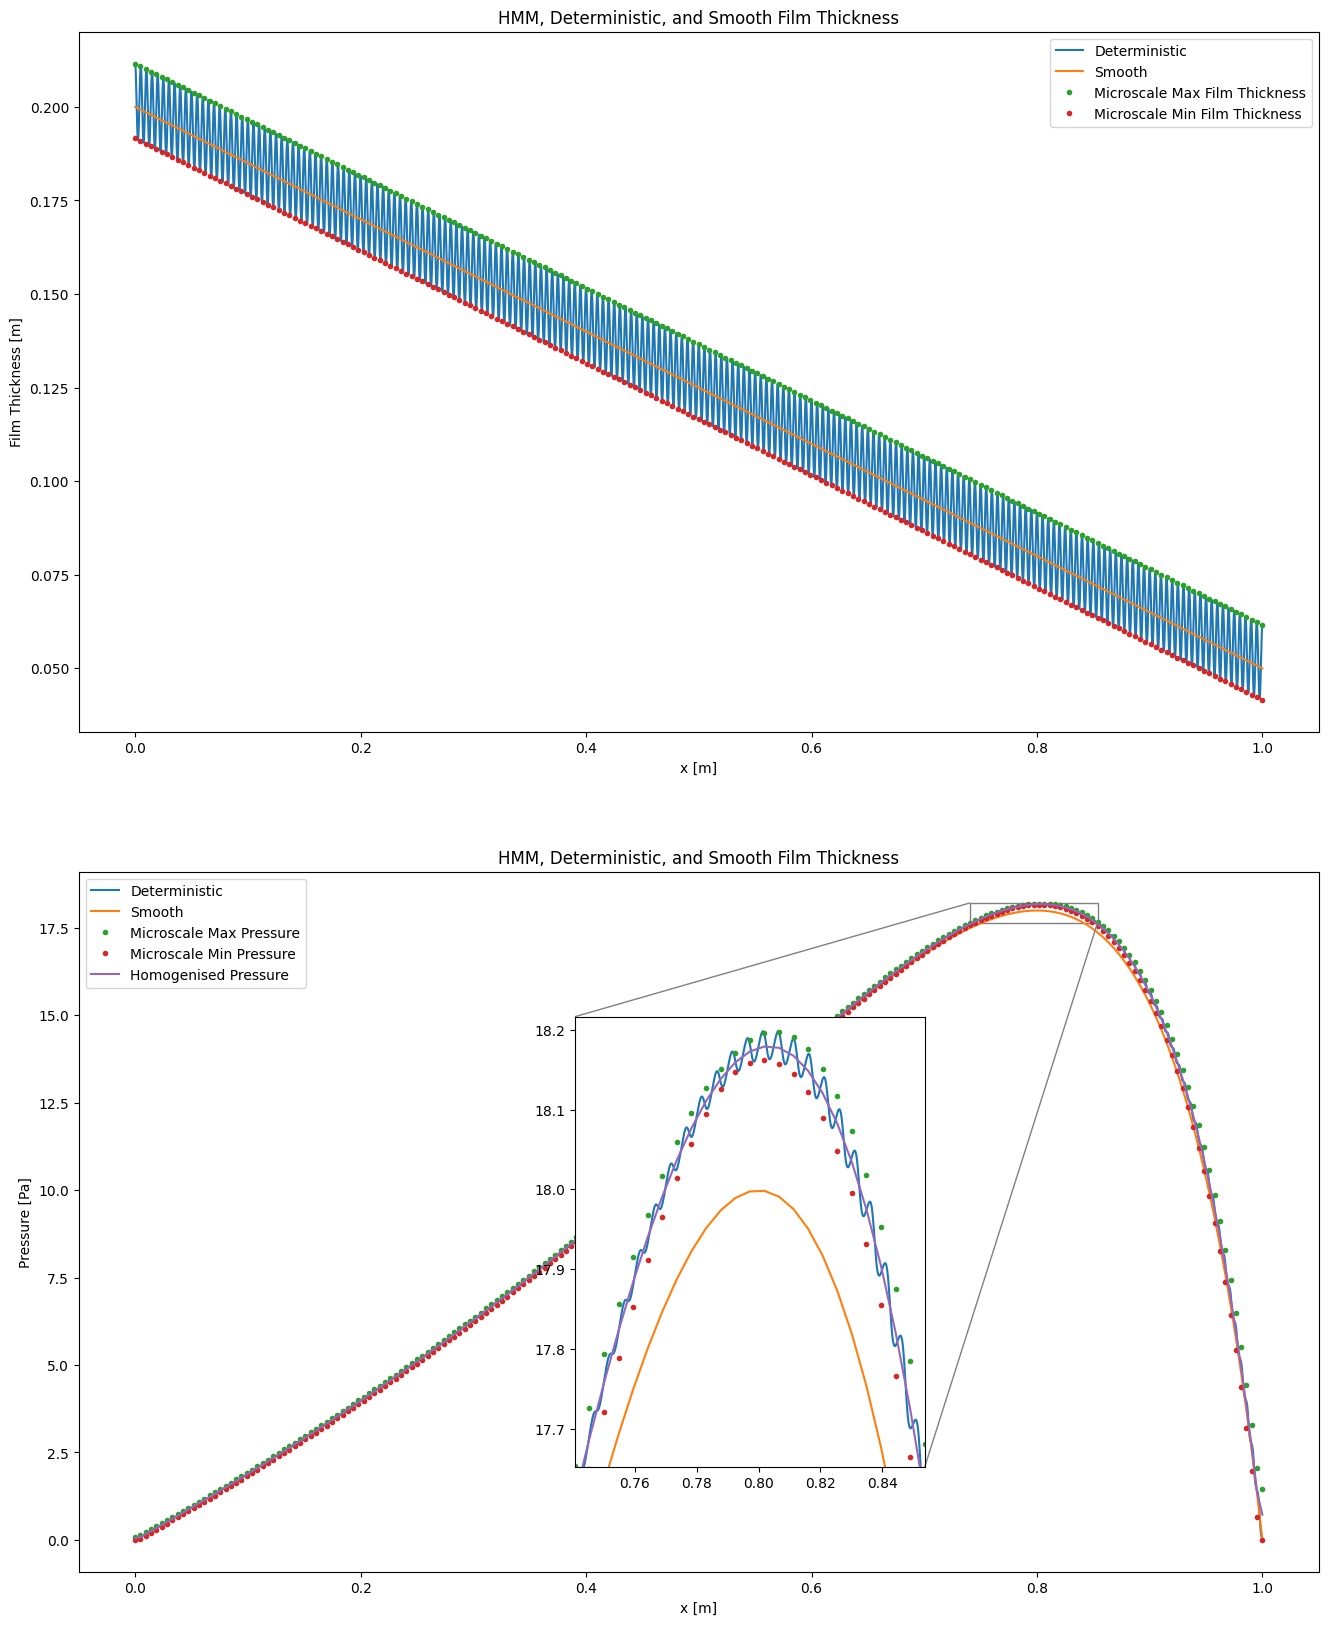

In [30]:
def plot_zeta_comparison(zeta_smooth, zeta_deterministic, micro_results=None, inset_loc=(0.4, 0.15, 3.5, 4.5)):
    x_vals_s = np.linspace(0, 1, np.size(zeta_smooth[0, :]))
    x_vals_d = np.linspace(0, 1, np.size(zeta_deterministic[0, :]))

    fig, axes = plt.subplots(2, 1, figsize=(16, 20))

    ax0 = axes[0]
    ax0.plot(x_vals_d, zeta_deterministic[0, :], label="Deterministic")
    ax0.plot(x_vals_s, zeta_smooth[0, :], label="Smooth")
    if micro_results is not None:
        ax0.plot(x_vals_s, micro_results[:, 4], ".", label="Microscale Max Film Thickness")
        ax0.plot(x_vals_s, micro_results[:, 5], ".", label="Microscale Min Film Thickness")
    ax0.set_xlabel("x [m]")
    ax0.set_ylabel("Film Thickness [m]")
    ax0.set_title("HMM, Deterministic, and Smooth Film Thickness")
    ax0.legend()

    ax1 = axes[1]
    l_d1, = ax1.plot(x_vals_d, zeta_deterministic[1, :], label="Deterministic")
    l_s1, = ax1.plot(x_vals_s, zeta_smooth[1, :], label="Smooth")

    ln_pst = None
    l_pmax = None
    l_pmin = None
    if micro_results is not None:
        l_pmax, = ax1.plot(x_vals_s, micro_results[:, 2], ".", label="Microscale Max Pressure")
        l_pmin, = ax1.plot(x_vals_s, micro_results[:, 3], ".", label="Microscale Min Pressure")
        ln_pst, = ax1.plot(x_vals_s, micro_results[:, 0], label="Homogenised Pressure")

    ax1.set_xlabel("x [m]")
    ax1.set_ylabel("Pressure [Pa]")
    ax1.set_title("HMM, Deterministic, and Smooth Film Thickness")
    ax1.legend()

    def add_inset_from_handles(ax, handles):
        xs = [np.asarray(h.get_xdata()) for h in handles]
        ys = [np.asarray(h.get_ydata()) for h in handles]

        if len(ys) == 0:
            return
        ymax = np.nanmax([np.nanmax(y) for y in ys if y.size > 0])
        if not np.isfinite(ymax):
            return

        y_low = ymax * (1 - 0.03)
        y_high = ymax * (1 + 0.001)

        x_dom_min = np.nanmin([np.nanmin(x) for x in xs if x.size > 0])
        x_dom_max = np.nanmax([np.nanmax(x) for x in xs if x.size > 0])
        x_dom = x_dom_max - x_dom_min

        xs_in_band = []
        for x, y in zip(xs, ys):
            if x.size == 0 or y.size == 0:
                continue
            mask = (y >= y_low) & (y <= y_high)
            if np.any(mask):
                xs_in_band.append(np.nanmin(x[mask]))
                xs_in_band.append(np.nanmax(x[mask]))

        if len(xs_in_band) == 0:
            x_at_ymax = None
            for x, y in zip(xs, ys):
                if y.size == 0:
                    continue
                idx = int(np.nanargmax(y))
                if np.isclose(y[idx], ymax):
                    x_at_ymax = x[idx]
                    break
            if x_at_ymax is None or not np.isfinite(x_at_ymax):
                return
            half_win = 0.05 * x_dom
            xmin = max(x_dom_min, x_at_ymax - half_win)
            xmax = min(x_dom_max, x_at_ymax + half_win)
        else:
            xmin = max(x_dom_min, np.nanmin(xs_in_band))
            xmax = min(x_dom_max, np.nanmax(xs_in_band))
            if xmax - xmin < 1e-6 * x_dom:
                pad = 0.02 * x_dom
                xmin = max(x_dom_min, xmin - pad)
                xmax = min(x_dom_max, xmax + pad)

        axins = inset_axes(
            ax, width=inset_loc[2], height=inset_loc[3],
            loc="lower left", bbox_to_anchor=inset_loc,
            bbox_transform=ax.transAxes, borderpad=0
        )

        for h in handles:
            x = np.asarray(h.get_xdata())
            y = np.asarray(h.get_ydata())
            if x.size == 0 or y.size == 0:
                continue
            axins.plot(
                x, y,
                linestyle=h.get_linestyle(),
                linewidth=h.get_linewidth(),
                marker=h.get_marker(),
                markersize=h.get_markersize(),
                markerfacecolor=h.get_markerfacecolor() if h.get_markerfacecolor() is not None else h.get_color(),
                markeredgecolor=h.get_markeredgecolor() if h.get_markeredgecolor() is not None else h.get_color(),
                color=h.get_color(),
                alpha=h.get_alpha() if h.get_alpha() is not None else 1.0,
                label=h.get_label(),
            )

        axins.set_xlim(xmin, xmax)
        axins.set_ylim(y_low, y_high)
        try:
            mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
        except Exception:
            pass

        return axins

    inset_handles = [l_d1, l_s1]
    if ln_pst is not None:
        inset_handles.append(ln_pst)
    if l_pmax is not None:
        inset_handles.append(l_pmax)
    if l_pmin is not None:
        inset_handles.append(l_pmin)

    add_inset_from_handles(ax1, inset_handles)
    plt.show()
plot_zeta_comparison(zeta_smooth, zeta_deterministic, micro_results)